# Optuna Hyperparameter Search — Top-4 Modelos (BAF Dataset)

**Contexto — ranking del benchmark anterior:**

| # | Modelo | AP Test |
|---|--------|---------|
| 1 | CatBoost | 0.1634 |
| 2 | XGBoost | 0.1530 |
| 3 | AdaBoost | 0.1515 |
| 4 | HistGradientBoosting | 0.1474 |

**Objetivo:** Búsqueda exhaustiva con Optuna (TPE) para cada uno de los 4 modelos,
usando el **30% del train** y validación cruzada de 5 folds dentro del Pipeline.

**Métrica principal:** `Average Precision (PR-AUC)`


## 1 · Importaciones

Se importan todas las librerías del experimento:
 - **`optuna`** con el sampler `TPESampler` para la búsqueda bayesiana de hiperparámetros (silencia el log verboso).
 - Los 4 modelos a comparar: `CatBoostClassifier`, `XGBClassifier`, `AdaBoostClassifier` y `HistGradientBoostingClassifier`.
 - `sklearn` para splits, validación cruzada y métricas (AP, ROC-AUC, F1, Recall, Precision).
 
 Fija las constantes globales: `N_TRIALS = 30` (intentos por modelo), `CV_FOLDS = 5` y `RANDOM_STATE = 42`.

In [ ]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import RobustScaler

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, cross_val_score
from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    f1_score, recall_score, precision_score, roc_auc_score,
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

RANDOM_STATE = 42
TARGET_COL   = 'fraud_bool'
N_TRIALS     = 30   
CV_FOLDS     = 5

print(f'  Optuna {optuna.__version__} | n_trials={N_TRIALS} | CV={CV_FOLDS} folds')


Librerias importadas.
  Optuna 4.8.0 | n_trials=30 | CV=5 folds


## 2 · Carga y splits

Se lee el CSV limpio y separa features y target.  
Realiza un `train_test_split` estratificado 80/20 % para reservar un **test definitivo** que los optimizadores de Optuna nunca verán.

In [ ]:
df = pd.read_csv('base-limpia.csv')
X  = df.drop(columns=[TARGET_COL])
y  = df[TARGET_COL]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

### 2.1 Subsplit del 30%

Del train completo, se extrae un **subconjunto estratificado del 30 %** (`X_opt`, `y_opt`) usando `StratifiedShuffleSplit`.  
 Este subconjunto es el que Optuna usará en cada trial: más grande que el 20 % del notebook anterior para dar más señal al optimizador, pero lo suficientemente pequeño para que 30 × 4 modelos × 5-fold CV sea ejecutable en tiempo razonable.

In [ ]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.70, random_state=RANDOM_STATE)
for idx_opt, _ in sss.split(X_train_full, y_train_full):
    X_opt = X_train_full.iloc[idx_opt].reset_index(drop=True)
    y_opt = y_train_full.iloc[idx_opt].reset_index(drop=True)


Se calcula el `ratio_desbalance` (nº de no-fraudes / nº de fraudes) e imprime un resumen con tamaños de cada split y porcentaje de fraude.  
 El ratio se usa después en `scale_pos_weight` de CatBoost y XGBoost para compensar el desbalance sin oversampling.

In [ ]:
ratio_desbalance = (y_opt == 0).sum() / (y_opt == 1).sum()

print(f'Dataset        : {df.shape[0]:,} filas | fraude {y.mean()*100:.2f}%')
print(f'Train completo : {X_train_full.shape[0]:,} muestras')
print(f'Test           : {X_test.shape[0]:,} muestras')
print(f'Optuna subset  : {X_opt.shape[0]:,} muestras (30% train) | fraude {y_opt.mean()*100:.2f}%')
print(f'Ratio 0:1      : {ratio_desbalance:.1f}:1')


Dataset        : 1,000,000 filas | fraude 1.10%
Train completo : 800,000 muestras
Test           : 200,000 muestras
Optuna subset  : 240,000 muestras (30% train) | fraude 1.10%
Ratio 0:1      : 89.7:1


## 3. Funciones Auxiliares

Se define `make_pipeline_native(model)`: un `ImbPipeline` de un solo paso que envuelve cualquier clasificador.  
No incluye oversampling (al contrario del notebook de estrategias), el desbalance se maneja de forma nativa por cada modelo, ya que era la mejor estrategia de muestreo, como ya se ha demostrado.

In [ ]:
def make_pipeline_native(model):
    """Pipeline SIN sobremuestreo"""
    return ImbPipeline(steps=[
        ('model',  model),
    ])

### 3.1 Función Auxiliar para maximizar el Threshold

Se define también `find_best_threshold(y_true, y_proba)`.  
Recorre la curva Precisión-Recall y devuelve el umbral de probabilidad que **maximiza el F1-score**.  
Esencial en datasets con ~1 % de fraude, donde el umbral por defecto (0.5) suele dar Recall cercano a cero.

In [ ]:
def find_best_threshold(y_true, y_proba):
    """Encuentra el umbral óptimo que maximiza el F1-score en la curva de precisión-recall."""
    prec, rec, thr = precision_recall_curve(y_true, y_proba)
    f1  = 2 * (prec * rec) / (prec + rec + 1e-10)
    idx = np.argmax(f1[:-1])
    return float(thr[idx]) if len(thr) > idx else 0.5

### 3.2 Función para evaluar el modelo

Se define `evaluate_on_test(name, pipeline)` que, dado un pipeline ya entrenado:  
1. Genera las probabilidades sobre el **test definitivo** (`X_test`).  
2. Calcula AP (PR-AUC) y ROC-AUC.  
3. Aplica `find_best_threshold` y clasifica con ese umbral.  
4. Devuelve un diccionario con todas las métricas + probabilidades crudas (para curvas PR).

In [ ]:
def evaluate_on_test(name, pipeline):
    """Evalúa el modelo final en el conjunto de test y devuelve las métricas."""
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    ap      = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    thr     = find_best_threshold(y_test, y_proba)
    y_pred  = (y_proba >= thr).astype(int)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    print(f'  AP={ap:.4f} | ROC-AUC={roc_auc:.4f} | F1={f1:.4f} | Recall={rec:.4f} | Precision={prec:.4f}')
    return {
        'Modelo':    name,
        'AP_optuna': None,
        'AP_test':   round(ap, 4),
        'ROC-AUC':   round(roc_auc, 4),
        'F1':        round(f1, 4),
        'Recall':    round(rec, 4),
        'Precision': round(prec, 4),
        'Threshold': round(thr, 4),
        '_y_proba':  y_proba,
    }

✅ Helpers definidos (pipeline sin SMOTE, nativo para boosters)


## 4 · Optuna — CatBoost

Se crea la función **`objective_catboost(trial)`**: función que Optuna llama en cada trial. 
1. Propone valores para 6 hiperparámetros (`iterations`, `depth`, `learning_rate`, `l2_leaf_reg`, `border_count`, `random_strength`) y devuelve el AP medio de 5-fold CV.  
2. Crea el estudio Optuna con dirección `maximize` y `TPESampler` (búsqueda bayesiana con árbol de Parzen).  
2. Lanza `n_trials=30` intentos y muestra el progreso.  
3. Con los mejores parámetros encontrados, **reentrena sobre todo `X_opt`** y evalúa en test con `evaluate_on_test`.  

El resultado queda en `result_cat` y `study_cat`.

In [ ]:
def objective_catboost(trial):
    params = {
        'iterations':      trial.suggest_int('iterations', 200, 700),
        'depth':           trial.suggest_int('depth', 4, 8),
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'l2_leaf_reg':     trial.suggest_int('l2_leaf_reg', 1, 15),
        'border_count':    trial.suggest_int('border_count', 32, 255),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10, log=True),
    }
    pipeline = make_pipeline_native(
        CatBoostClassifier(
            **params,
            scale_pos_weight=ratio_desbalance,
            random_seed=RANDOM_STATE,
            eval_metric='PRAUC',
            thread_count=-1,
            verbose=False,
        )
    )
    scores = cross_val_score(pipeline, X_opt, y_opt,
                             cv=CV_FOLDS, scoring='average_precision', n_jobs=-1)
    return scores.mean()


print('=' * 60)
print('CatBoost — Optuna TPE Search (sin SMOTE)')
print('=' * 60)
t0 = time.time()

study_cat = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
study_cat.optimize(objective_catboost, n_trials=N_TRIALS, show_progress_bar=True)

print(f'  Mejor AP CV   : {study_cat.best_value:.4f}')
print(f'  Mejores params: {study_cat.best_params}')
print(f'  Tiempo        : {time.time()-t0:.1f}s')

pipeline_cat = make_pipeline_native(
    CatBoostClassifier(
        **study_cat.best_params,
        scale_pos_weight=ratio_desbalance,
        random_seed=RANDOM_STATE,
        eval_metric='PRAUC',
        thread_count=-1,
        verbose=False,
    )
)
pipeline_cat.fit(X_opt, y_opt)
print('  Evaluacion en TEST:')
result_cat = evaluate_on_test('CatBoost', pipeline_cat)
result_cat['AP_optuna'] = round(study_cat.best_value, 4)
result_cat['Tiempo_s']  = round(time.time()-t0, 1)

CatBoost — Optuna TPE Search (sin SMOTE)


Best trial: 23. Best value: 0.173432: 100%|██████████| 30/30 [20:20<00:00, 40.69s/it]


  Mejor AP CV   : 0.1734
  Mejores params: {'iterations': 622, 'depth': 4, 'learning_rate': 0.03965120054095257, 'l2_leaf_reg': 7, 'border_count': 116, 'random_strength': 1.443642998434956e-06}
  Tiempo        : 1220.6s
  Evaluacion en TEST:
  AP=0.1778 | ROC-AUC=0.8948 | F1=0.2454 | Recall=0.3073 | Precision=0.2042


## 5 · Optuna — XGBoost

Misma estructura que CatBoost. Explora 9 hiperparámetros de XGBoost: `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `min_child_weight`, `gamma`, `reg_alpha` y `reg_lambda`.  



Usa `scale_pos_weight=ratio_desbalance` y `eval_metric='aucpr'` para que XGBoost también maneje el desbalance de forma nativa.  
Resultado en `result_xgb` y `study_xgb`.

In [ ]:
def objective_xgboost(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 500),
        'max_depth':       trial.suggest_int('max_depth', 3, 8),
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample':       trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':trial.suggest_int('min_child_weight', 1, 20),
        'gamma':           trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha':       trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':      trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
    }
    
    pipeline = make_pipeline_native(
        XGBClassifier(
            **params,
            scale_pos_weight=ratio_desbalance,
            eval_metric='aucpr',
            n_jobs=-1,
            verbosity=0,
            random_state=RANDOM_STATE,
        )
    )
    scores = cross_val_score(pipeline, X_opt, y_opt,
                             cv=CV_FOLDS, scoring='average_precision', n_jobs=-1)
    return scores.mean()


print('=' * 60)
print('XGBoost — Optuna TPE Search (sin SMOTE)')
print('=' * 60)
t0 = time.time()

study_xgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(objective_xgboost, n_trials=N_TRIALS, show_progress_bar=True)

print(f'  Mejor AP CV   : {study_xgb.best_value:.4f}')
print(f'  Mejores params: {study_xgb.best_params}')
print(f'  Tiempo        : {time.time()-t0:.1f}s')


pipeline_xgb = make_pipeline_native(
    XGBClassifier(
        **study_xgb.best_params,
        scale_pos_weight=ratio_desbalance,
        eval_metric='aucpr',
        n_jobs=-1,
        verbosity=0,
        random_state=RANDOM_STATE,
    )
)
pipeline_xgb.fit(X_opt, y_opt)
print('  Evaluacion en TEST:')
result_xgb = evaluate_on_test('XGBoost', pipeline_xgb)
result_xgb['AP_optuna'] = round(study_xgb.best_value, 4)
result_xgb['Tiempo_s']  = round(time.time()-t0, 1)

XGBoost — Optuna TPE Search (sin SMOTE)


Best trial: 22. Best value: 0.171704: 100%|██████████| 30/30 [06:13<00:00, 12.44s/it]


  Mejor AP CV   : 0.1717
  Mejores params: {'n_estimators': 333, 'max_depth': 3, 'learning_rate': 0.06956510967181562, 'subsample': 0.764922571015163, 'colsample_bytree': 0.639049825253563, 'min_child_weight': 10, 'gamma': 4.6329001339503755, 'reg_alpha': 0.0420713649304392, 'reg_lambda': 0.0002564906683768077}
  Tiempo        : 373.3s
  Evaluacion en TEST:
  AP=0.1738 | ROC-AUC=0.8958 | F1=0.2423 | Recall=0.2756 | Precision=0.2161


## 6 · Optuna — AdaBoost

Misma estructura que las anteriores. AdaBoost no tiene `scale_pos_weight` nativo, así que el desbalance se gestiona indirectamente.   



Optimiza 3 hiperparámetros: `n_estimators`, `learning_rate` y `base_depth` (profundidad del árbol base `DecisionTreeClassifier`).  

In [ ]:
def objective_adaboost(trial):
    base_depth = trial.suggest_int('base_depth', 1, 4)
    params = {
        'n_estimators':  trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
    }
    
    pipeline = make_pipeline_native(
        AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=base_depth, random_state=RANDOM_STATE),
            **params,
            random_state=RANDOM_STATE,
        )
    )
    scores = cross_val_score(pipeline, X_opt, y_opt,
                             cv=CV_FOLDS, scoring='average_precision', n_jobs=-1)
    return scores.mean()


print('=' * 60)
print('AdaBoost — Optuna TPE Search (sin SMOTE)')
print('=' * 60)
t0 = time.time()

study_ada = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
study_ada.optimize(objective_adaboost, n_trials=N_TRIALS, show_progress_bar=True)

print(f'  Mejor AP CV   : {study_ada.best_value:.4f}')
print(f'  Mejores params: {study_ada.best_params}')
print(f'  Tiempo        : {time.time()-t0:.1f}s')

best_ada_params = study_ada.best_params.copy()
base_d = best_ada_params.pop('base_depth')

pipeline_ada = make_pipeline_native(
    AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=base_d, random_state=RANDOM_STATE),
        **best_ada_params,
        random_state=RANDOM_STATE,
    )
)
pipeline_ada.fit(X_opt, y_opt)
print('  Evaluacion en TEST:')
result_ada = evaluate_on_test('AdaBoost', pipeline_ada)
result_ada['AP_optuna'] = round(study_ada.best_value, 4)
result_ada['Tiempo_s']  = round(time.time()-t0, 1)

AdaBoost — Optuna TPE Search (sin SMOTE)


Best trial: 22. Best value: 0.168449: 100%|██████████| 30/30 [2:17:55<00:00, 275.84s/it]  


  Mejor AP CV   : 0.1684
  Mejores params: {'base_depth': 1, 'n_estimators': 451, 'learning_rate': 0.553977267571749}
  Tiempo        : 8275.3s
  Evaluacion en TEST:
  AP=0.1727 | ROC-AUC=0.8931 | F1=0.2436 | Recall=0.2792 | Precision=0.2160


## 7 · Optuna — HistGradientBoosting

Usando la misma estructura, HistGradientBoosting usa `class_weight='balanced'` en lugar de `scale_pos_weight`.  


Explora 6 hiperparámetros: `max_iter`, `learning_rate`, `max_depth`, `min_samples_leaf`, `l2_regularization` y `max_leaf_nodes`.  
Resultado en `result_hgb` y `study_hgb`.

In [ ]:
def objective_histgb(trial):
    params = {
        'max_iter':          trial.suggest_int('max_iter', 100, 500),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 5, 50),
        'l2_regularization': trial.suggest_float('l2_regularization', 1e-8, 1.0, log=True),
        'max_leaf_nodes':    trial.suggest_int('max_leaf_nodes', 15, 63),
    }
    
    pipeline = make_pipeline_native(
        HistGradientBoostingClassifier(
            **params,
            class_weight='balanced',
            random_state=RANDOM_STATE,
        )
    )
    scores = cross_val_score(pipeline, X_opt, y_opt,
                             cv=CV_FOLDS, scoring='average_precision', n_jobs=-1)
    return scores.mean()


print('=' * 60)
print('HistGradientBoosting — Optuna TPE Search (sin SMOTE)')
print('=' * 60)
t0 = time.time()

study_hgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
study_hgb.optimize(objective_histgb, n_trials=N_TRIALS, show_progress_bar=True)

print(f'  Mejor AP CV   : {study_hgb.best_value:.4f}')
print(f'  Mejores params: {study_hgb.best_params}')
print(f'  Tiempo        : {time.time()-t0:.1f}s')


pipeline_hgb = make_pipeline_native(
    HistGradientBoostingClassifier(
        **study_hgb.best_params,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    )
)
pipeline_hgb.fit(X_opt, y_opt)
print('  Evaluacion en TEST:')
result_hgb = evaluate_on_test('HistGradientBoosting', pipeline_hgb)
result_hgb['AP_optuna'] = round(study_hgb.best_value, 4)
result_hgb['Tiempo_s']  = round(time.time()-t0, 1)

HistGradientBoosting — Optuna TPE Search (sin SMOTE)


Best trial: 9. Best value: 0.166113: 100%|██████████| 30/30 [07:42<00:00, 15.41s/it]


  Mejor AP CV   : 0.1661
  Mejores params: {'max_iter': 339, 'learning_rate': 0.15826541904647565, 'max_depth': 3, 'min_samples_leaf': 14, 'l2_regularization': 2.300479202014574e-08, 'max_leaf_nodes': 30}
  Tiempo        : 462.2s
  Evaluacion en TEST:
  AP=0.1651 | ROC-AUC=0.8924 | F1=0.2378 | Recall=0.2915 | Precision=0.2009


## 8 · Ranking final

En cuanto al ranking, agrupa los 4 `result_*` en un DataFrame `df_rank`, ordenado por `AP_test` descendente.  
Añade la columna `Gap_CV-Test` = AP_optuna − AP_test: un gap alto (>0.02, en rojo) indica **overfitting al subconjunto de Optuna**.  
Intenta renderizar una tabla estilizada con Jupyter: oro para el ganador, verde/azul para 2.º y 3.º puesto.

In [13]:
all_results = [result_cat, result_xgb, result_ada, result_hgb]

cols = ['Modelo','AP_optuna','AP_test','ROC-AUC','F1','Recall','Precision','Threshold','Tiempo_s']
df_rank = (
    pd.DataFrame([{k: v for k,v in r.items() if not k.startswith('_')}
                  for r in all_results])
    [cols]
    .sort_values('AP_test', ascending=False)
    .reset_index(drop=True)
)
df_rank.index += 1
df_rank['Gap_CV-Test'] = (df_rank['AP_optuna'] - df_rank['AP_test']).round(4)

print('RANKING FINAL — Optuna Top-4')
print('=' * 70)
print(df_rank.to_string())
print('=' * 70)

try:
    def highlight_top(s):
        colors = ['background-color: #f9e79f; font-weight:bold',
                  'background-color: #d5f5e3',
                  'background-color: #d6eaf8', '']
        return colors[:len(s)]

    def color_gap(val):
        if pd.isna(val): return ''
        return 'color: #e74c3c; font-weight:bold' if val > 0.02 else 'color: #27ae60'

    fmt = {c: '{:.4f}' for c in ['AP_optuna','AP_test','ROC-AUC','F1',
                                   'Recall','Precision','Threshold','Gap_CV-Test']}
    fmt['Tiempo_s'] = '{:.1f}s'

    display(
        df_rank.style
        .apply(highlight_top, subset=['AP_test'])
        .map(color_gap, subset=['Gap_CV-Test'])
        .format(fmt)
        .set_caption('Optuna Top-4 — 30% train | Test 20% original')
        .set_table_styles([{'selector':'th',
                            'props':[('background-color','#2c3e50'),
                                     ('color','white'),('text-align','center')]}])
    )
except Exception:
    pass


RANKING FINAL — Optuna Top-4
                 Modelo  AP_optuna  AP_test  ROC-AUC      F1  Recall  Precision  Threshold  Tiempo_s  Gap_CV-Test
1              CatBoost     0.1734   0.1778   0.8948  0.2454  0.3073     0.2042     0.8920    1245.2      -0.0044
2               XGBoost     0.1717   0.1738   0.8958  0.2423  0.2756     0.2161     0.9083     376.0      -0.0021
3              AdaBoost     0.1684   0.1727   0.8931  0.2436  0.2792     0.2160     0.4393    8503.6      -0.0043
4  HistGradientBoosting     0.1661   0.1651   0.8924  0.2378  0.2915     0.2009     0.8946     467.4       0.0010


,Modelo,AP_optuna,AP_test,ROC-AUC,F1,Recall,Precision,Threshold,Tiempo_s,Gap_CV-Test
1,CatBoost,0.1734,0.1778,0.8948,0.2454,0.3073,0.2042,0.8920,1245.2s,-0.0044
2,XGBoost,0.1717,0.1738,0.8958,0.2423,0.2756,0.2161,0.9083,376.0s,-0.0021
3,AdaBoost,0.1684,0.1727,0.8931,0.2436,0.2792,0.2160,0.4393,8503.6s,-0.0043
4,HistGradientBoosting,0.1661,0.1651,0.8924,0.2378,0.2915,0.2009,0.8946,467.4s,0.0010


## 9 · Visualizaciones

Genera una figura de 3 subplots comparativos:  
1. **AP CV (Optuna) vs AP Test** — barras agrupadas; la diferencia visual entre ambas barras revela el gap de generalización.  
2. **F1 / Recall / Precision** — barras agrupadas por métrica y modelo; útil para ver el trade-off precisión-recall de cada algoritmo.  
3. **Curvas PR** — curvas Precisión-Recall sobre el test real; el modelo ganador aparece con línea sólida y más gruesa.  

Guarda la figura en `optuna_top4_results.png`.

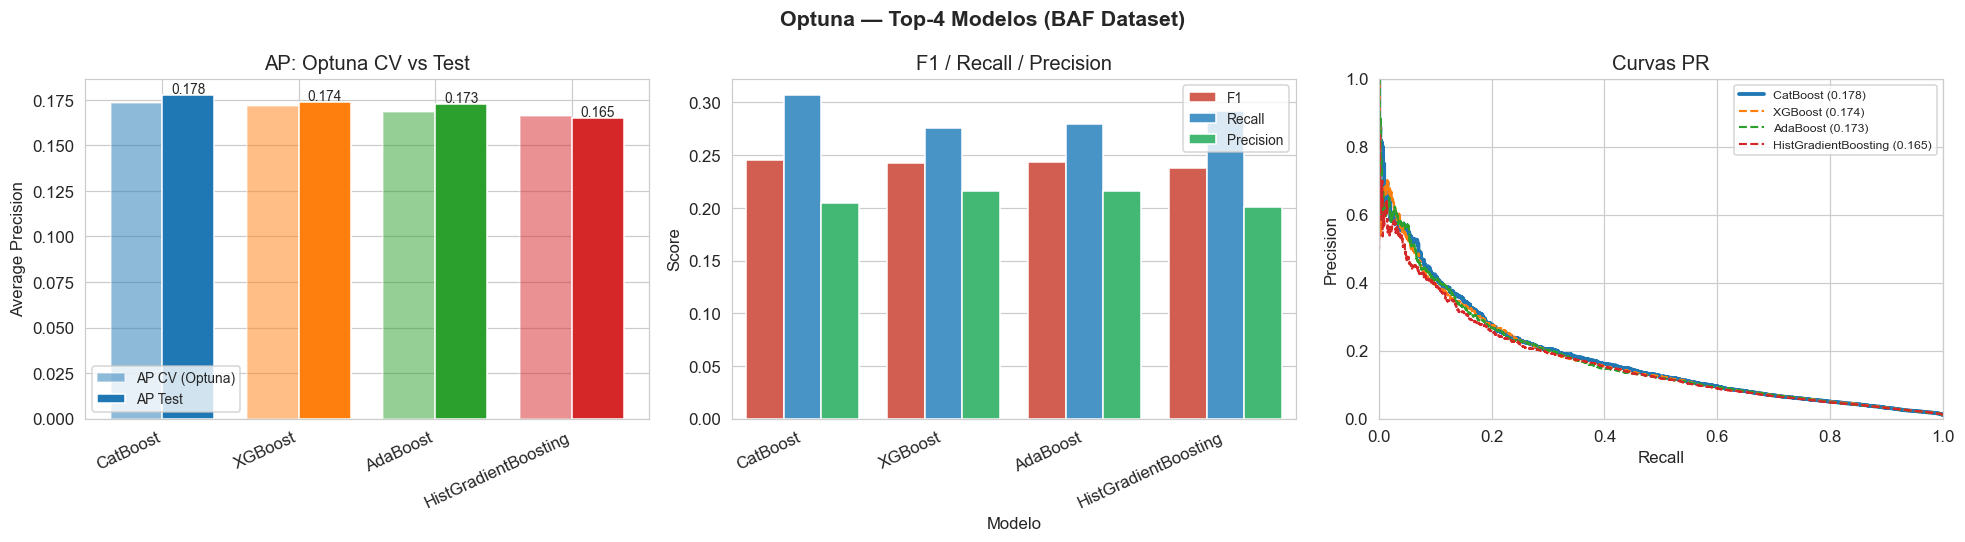

Grafico guardado -> optuna_top4_results.png


In [14]:
modelos   = df_rank['Modelo'].tolist()
palette   = sns.color_palette('tab10', len(modelos))
color_map = dict(zip(modelos, palette))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Optuna — Top-4 Modelos (BAF Dataset)', fontsize=14, fontweight='bold')

# AP CV vs Test
ax = axes[0]
x, w = np.arange(len(modelos)), 0.38
ax.bar(x - w/2, df_rank['AP_optuna'], width=w, label='AP CV (Optuna)',
       color=[color_map[m] for m in modelos], alpha=0.5, edgecolor='white')
bars = ax.bar(x + w/2, df_rank['AP_test'], width=w, label='AP Test',
              color=[color_map[m] for m in modelos], alpha=1.0, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(modelos, rotation=25, ha='right')
ax.set_ylabel('Average Precision'); ax.set_title('AP: Optuna CV vs Test')
ax.legend(fontsize=9)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.001,
            f'{b.get_height():.3f}', ha='center', fontsize=9)

# F1 / Recall / Precision
ax = axes[1]
df_melt = df_rank[['Modelo','F1','Recall','Precision']].melt(
    id_vars='Modelo', var_name='Metrica', value_name='Valor')
sns.barplot(data=df_melt, x='Modelo', y='Valor', hue='Metrica',
            palette=['#e74c3c','#3498db','#2ecc71'], ax=ax)
ax.set_xticklabels(modelos, rotation=25, ha='right')
ax.set_title('F1 / Recall / Precision'); ax.set_ylabel('Score')
ax.legend(fontsize=9)

# Curvas PR
ax = axes[2]
for r in all_results:
    m = r['Modelo']
    prec_c, rec_c, _ = precision_recall_curve(y_test, r['_y_proba'])
    lw = 2.5 if m == df_rank.iloc[0]['Modelo'] else 1.4
    ls = '-'  if m == df_rank.iloc[0]['Modelo'] else '--'
    ax.plot(rec_c, prec_c, label=f"{m} ({r['AP_test']:.3f})",
            linewidth=lw, linestyle=ls, color=color_map[m])
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Curvas PR'); ax.legend(fontsize=8, loc='upper right')
ax.set_xlim([0,1]); ax.set_ylim([0,1])

plt.tight_layout()
plt.savefig('optuna_top4_results.png', bbox_inches='tight', dpi=150)
plt.show()
print('Grafico guardado -> optuna_top4_results.png')


## 10 · Convergencia de Optuna

Genera una figura 2×2 con la **curva de convergencia** de cada estudio Optuna:  
- Puntos dispersos: AP de cada trial individual.  
- Línea continua: mejor AP acumulado hasta ese trial.  
- Línea discontinua: valor óptimo final.  

Permite detectar si Optuna convergió prematuramente (plateau temprano) o si merecería más trials.  
Guarda la figura en `optuna_convergencia.png`.

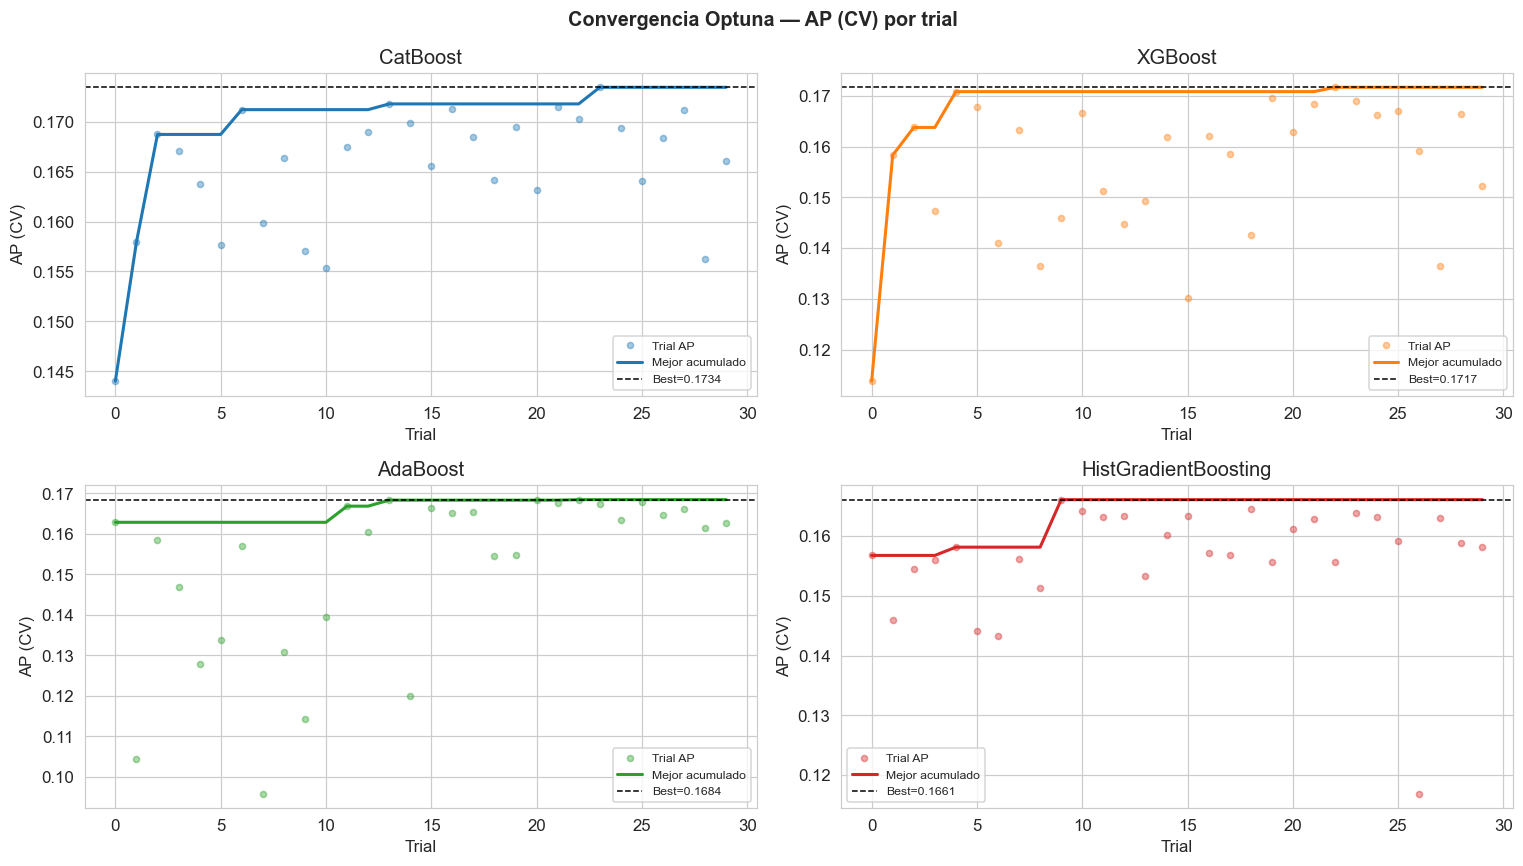

Grafico guardado -> optuna_convergencia.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Convergencia Optuna — AP (CV) por trial', fontsize=13, fontweight='bold')

studies = [(study_cat,'CatBoost'),(study_xgb,'XGBoost'),
           (study_ada,'AdaBoost'),(study_hgb,'HistGradientBoosting')]

for ax, (study, name) in zip(axes.flat, studies):
    vals = [t.value for t in study.trials if t.value is not None]
    best_accum = np.maximum.accumulate(vals)
    ax.plot(vals, 'o', alpha=0.4, markersize=4, color=color_map[name], label='Trial AP')
    ax.plot(best_accum, '-', linewidth=2, color=color_map[name], label='Mejor acumulado')
    ax.axhline(study.best_value, color='black', linestyle='--', linewidth=1,
               label=f'Best={study.best_value:.4f}')
    ax.set_title(name); ax.set_xlabel('Trial'); ax.set_ylabel('AP (CV)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('optuna_convergencia.png', bbox_inches='tight', dpi=150)
plt.show()
print('Grafico guardado -> optuna_convergencia.png')
